# NFG Explained

#### 1. Initialize environment

In [1]:
from ri_motion_v5_package.init_scripts.init_ipython_setup import *
from ri_motion_v5_package.init_scripts.init_qt import *
from ri_motion_v5_package.mujoco_sim import *
from ri_motion_v5_package.kinematics import *
from ri_motion_v5_package.utility import *
from ri_motion_v5_package.qt import *
# trajectory tools 
from ri_motion_v5_package.traj_optimization.traj_utils import *
from ri_motion_v5_package.traj_optimization.traj_shaper import *
# gp tools 
from ri_motion_v5_package.gaussian_process.gp_utils import *
from ri_motion_v5_package.gaussian_process.kernels import rbf_kernel

from package.panda_env import * 

from PyQt5.QtWidgets import QApplication
app = QApplication(sys.argv)

Basic packages initialized.
 import numpy as np
 import matplotlib.pyplot as plt
 import scipy as sp
 from PIL import Image
[ipython] settings (retina, inline, qt) initialized.
[numpy] settings initialized.
[matplotlib] settings initialized.
[qt] package initialized.


In [2]:
xml_path = merge_mjcfs(
    included_mjcf_files = [
        '../../asset/floor/floor_white_gray.xml',
        './asset/panda_inspire/panda_inspire_site_added.xml',
        './asset/cabinet/cabinet_half_closed.xml',
        './asset/object/cylinder.xml',
    ],
    output_xml_path = 'xml/panda_cabinet_scene.xml',
)
env = MuJoCoParser(rel_xml_path=xml_path,verbose=True)

[merge_mjcfs] Merging [4] MJCF files:
  - [0] [../../asset/floor/floor_white_gray.xml]
  - [1] [./asset/panda_inspire/panda_inspire_site_added.xml]
  - [2] [./asset/cabinet/cabinet_half_closed.xml]
  - [3] [./asset/object/cylinder.xml]
[merge_mjcfs] Saved merged XML to:[xml/panda_cabinet_scene.xml]

-----------------------------------------------------------------------------
name:[scene] dt:[0.002] HZ:[500]
 n_q:[26] n_v:[25] n_u:[7]
 integrator:[IMPLICITFAST]

Body information. n_body:[28]
 [0/28] [world] parent:[world] mass:[0.00]kg
 [1/28] [panda_base] parent:[world] mass:[0.00]kg
 [2/28] [panda_link_0] parent:[panda_base] mass:[4.00]kg
 [3/28] [panda_link_1] parent:[panda_link_0] mass:[3.00]kg
 [4/28] [panda_link_2] parent:[panda_link_1] mass:[3.00]kg
 [5/28] [panda_link_3] parent:[panda_link_2] mass:[2.00]kg
 [6/28] [panda_link_4] parent:[panda_link_3] mass:[2.00]kg
 [7/28] [panda_link_5] parent:[panda_link_4] mass:[2.00]kg
 [8/28] [panda_link_6] parent:[panda_link_5] mass:[1.50]

#### 2. Intialize environment and generate smooth trajectory

In [3]:
# Configurations
panda_joints          = get_panda_joint_names()
inspire_joints        = get_inspire_joint_names()
inspire_active_joints = env.get_active_among_joints(inspire_joints)
p_cylinder_offset0    = get_p_offset_palm_to_cylinder()
qactive_inspire0      = get_qactive_inspire()
q_inspire0            = get_q_inspire(env)
q_pandas              = get_q_pandas_cabinet()

# Compute piecewise linear trajectories from init to final
anchors = np.vstack((q_pandas['init'],q_pandas['final'])) # (M x dim)
n_anchor,dim = anchors.shape[0],anchors.shape[1]
res = get_interp_const_vel_traj_nd(
    anchors = anchors, # (M x dim)
    vel     = 90*D2R, # maximum velocity
    Hz      = 20,
)
times        = res['times_interp'] # (L)
trajs_lin    = res['anchors_interp'] # (L x dim)
times_anchor = res['times_anchor'] # (M,)
idxs_anchor  = res['idxs_anchor'] # (M,)
L,t_max = times.shape[0],times[1]

# Smooth joint trajectory
trajs_smt = np.zeros_like(trajs_lin) # (L x dim)
for d_idx in range(dim):
    res = traj_1d_shaper(
        t        = times, # (L,)
        x_ref    = trajs_lin[:,d_idx], # (L)
        idxs_eq  = idxs_anchor, # (M,)
        vals_eq  = anchors[:,d_idx], #(M,)
        v_init   = 0.0,
        v_final  = 0.0,
        lambda_j = 1e-4,
    )
    trajs_smt[:,d_idx] = res['z'] # (L,)

#### 3. Define Hilbert space & Set NFG parameters

In [4]:
# Define (mean-zero) Hilbert space
t_max  = times[-1]
t_in   = np.array([0,t_max])
t_out  = np.linspace(0.0,t_max,L)
hyp    = {'length_scale':0.5*t_max,'variance':1.0}
K_chol = get_schur_K_chol(t_in,t_out,rbf_kernel,hyp)

# Set NFG parameters
n_traj          = 100
topk            = 20
seed            = 0
use_uniform     = True
trim            = True # if False, use fix_scale
squash_margin   = 0.0
contact_gain    = 10.0
motion_gain     = 5.0
stepsize        = 0.5 

#### 4. Iterate

In [5]:
# initialize trajectory
traj_update = trajs_smt.copy() # (L x dim)
list_traj_result = [traj_update.copy()]

# initialize score 
scores = np.zeros((n_traj,))

# Initialize env and viewer
set_panda_cabinet_env(env,panda_joints,inspire_joints,q_pandas['init'],q_inspire0, initialize_viewer=False)

# sample trajectories 
trajs_list_mz = sample_trajs_multidim(
    K_chol      = K_chol,
    n_traj      = n_traj,
    d           = dim,
    use_uniform = True,
) # (L x n_traj x dim)
trajs_list_ms = trajs_list_mz + trajs_smt[:,None,:] # (L x n_traj x dim)

# Soft squash (sq)
x_mins = env.get_joint_mins(panda_joints)
x_maxs = env.get_joint_maxs(panda_joints)
trajs_list_sq = soft_squash_multidim(
    trajs_list_ms,x_min=x_mins,x_max=x_maxs,margin=squash_margin,dim_axis=2,
) # (L x n_traj x dim)

# # Calculate motion score (= trajectory length)
traj_diff = np.diff(trajs_list_sq, axis=0)
score_length = np.sum(np.linalg.norm(traj_diff, axis=0), axis=1)  # (n_traj,)

# calculate contact score
for traj_idx in range(n_traj):
    traj = trajs_list_sq[:,traj_idx,:] # L x dim
    score_traj_single = np.zeros(L)
    for _step in range(L):
        env.forward(q = traj[_step,:], joint_names=panda_joints)
        T_palm = get_T_palm_panda_inspire(env)
        p_cylinder_offset = p_cylinder_offset0
        T_cylinder = view_in_world(T=p2t(p_cylinder_offset),T_wl=T_palm)
        env.set_T('body_cylinder','base_body',T_cylinder)
        contact_info = env.get_contact_info()
        n_contact = contact_info['n_contact'] 
        min_contact_dist = contact_info['min_contact_dist'] 
        if min_contact_dist > 0: score = 0.0 # if no contact, score is 0 
        else: score = n_contact*min_contact_dist # if contact, number of contact and minimum contact distance is multiplied
        score_traj_single[_step] = score
    scores[traj_idx] = score_traj_single.min() # Append minimum (worst case) score (per trajectory)

# terimnalize if contact-free trajectory is found
if np.any(scores  == 0.0):
    print_yellow("Contact-free trajectory found, terminalizing optimization.")
    solved_idx = np.where(scores == 0.0)[0][0]
    best_traj = trajs_list_sq[:,solved_idx,:]

# calculate total score & update trajectory
scores += scores * contact_gain - motion_gain * score_length
topk_idx       = np.argsort(scores)[-topk:]
epsilon_topk   = trajs_list_mz[:, topk_idx, :]     # (L, k, dim)
scores_topk    = scores[topk_idx]
score_sum      = np.sum(scores_topk)/len(scores_topk)
score_shifted  = scores_topk-scores_topk.max()
score_pt       = power_transform(score_shifted, T=0.1, p=20, mode='exp')
weight         = score_pt / score_pt.sum()
weighted_epsilon = epsilon_topk * weight[np.newaxis, :, np.newaxis]
gradient       = np.sum(weighted_epsilon, axis=1) # L x n x dof
gradient       = trim_scale(gradient, th=stepsize) if trim else fix_scale(gradient, th=stepsize)

traj_update = traj_update + gradient
list_traj_result.append(traj_update.copy())

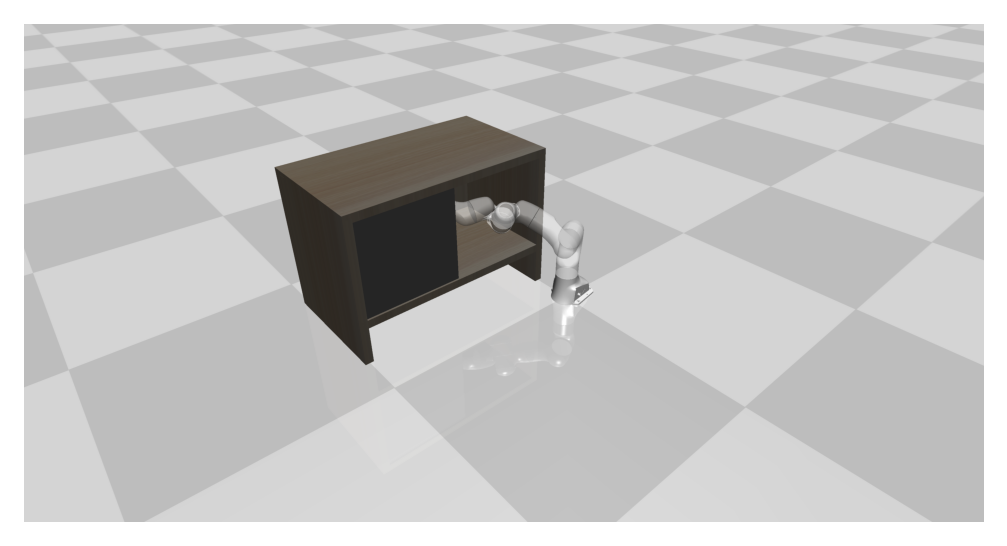

Done.


In [6]:
animate_cabinet_env_traj(
    env                = env,
    mode_str           = "NFG_single_step",
    traj               = traj_update,
    panda_joints       = panda_joints,
    inspire_joints     = inspire_joints,
    q_pandas           = q_pandas,
    q_inspire0         = q_inspire0,
    p_cylinder_offset0 = p_cylinder_offset0,
    ubuntu_process_events_flag = True,
    app=app,
)
imshow(env.final_rgb_img)
print ("Done.")

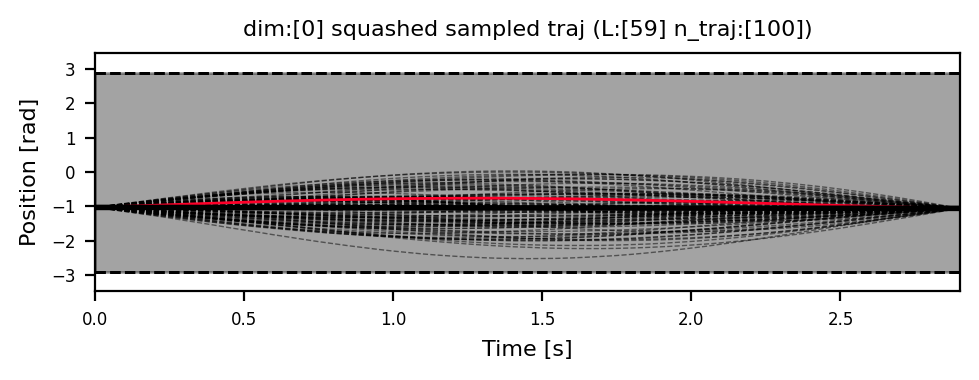

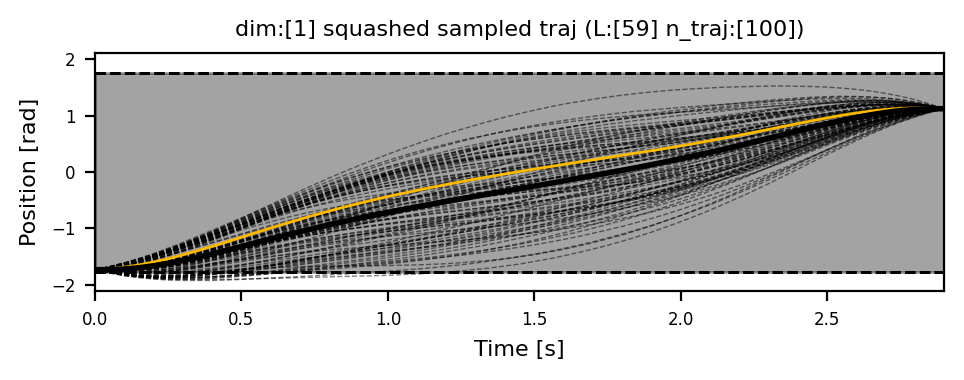

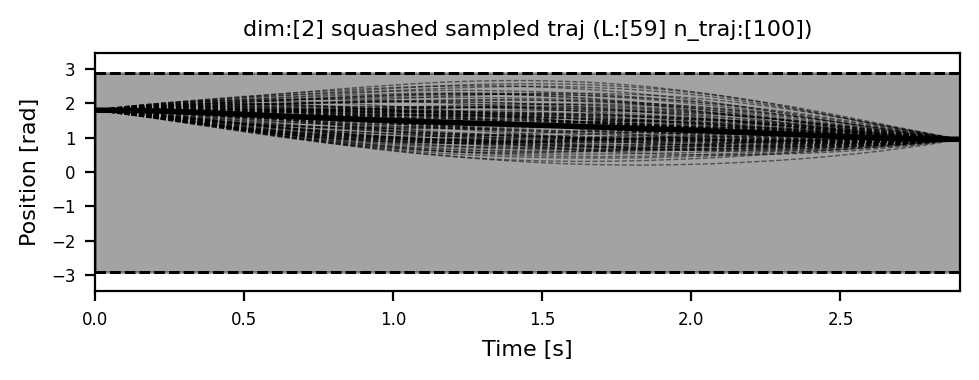

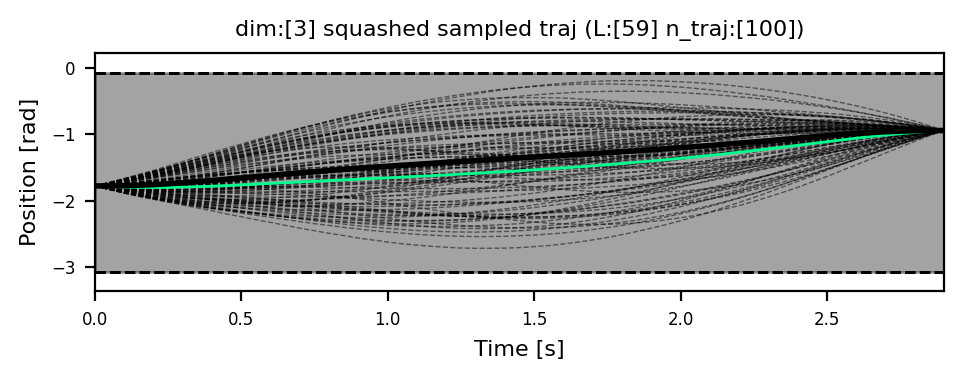

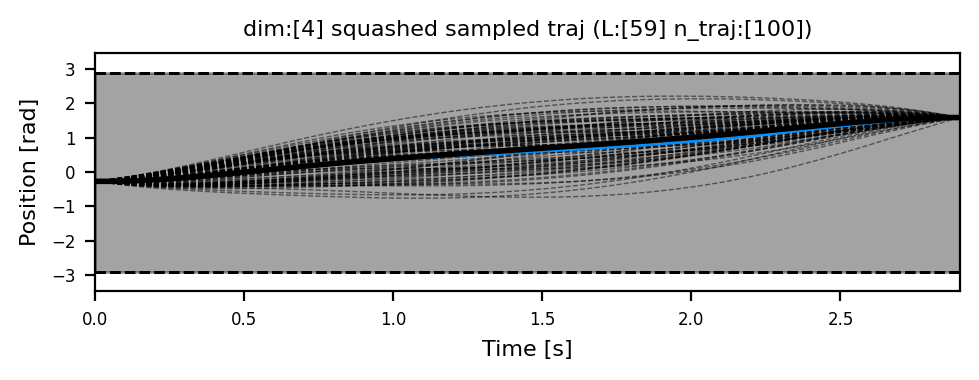

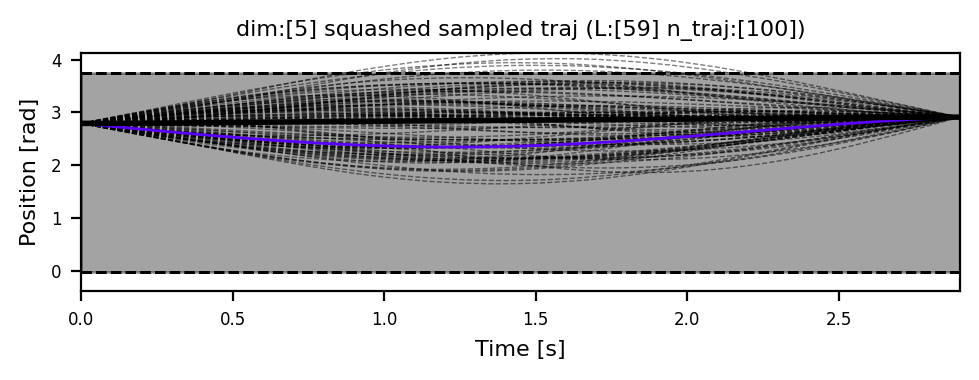

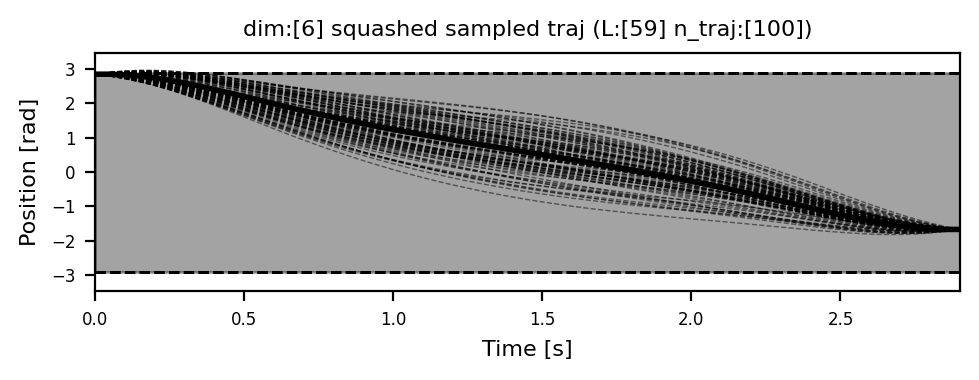

In [7]:
# Plot sampled trajctories
colors = get_colors(n_color=dim,cmap_name='gist_rainbow')
for d_idx in range(dim): # for each dim
    plt.figure(figsize=(5,2))
    traj_ms  = trajs_list_ms[:,:,d_idx] # (L,n_traj)
    # visualize optimization trajectory history: (n_iter, L, dim) -> select d_idx -> (L, n_iter)
    traj_hist = np.stack(list_traj_result, axis=0)  # (n_iter, L, dim)
    traj_sq = traj_hist[:, :, d_idx].T              # (L, n_iter)
    traj_smt = trajs_smt[:,d_idx]  # (L,)
    rgba     = colors[d_idx]
    plt.fill_between(t_out,x_mins[d_idx],x_maxs[d_idx],color='k',alpha=0.2)
    plt.fill_between(t_out,x_mins[d_idx]+squash_margin,x_maxs[d_idx]-squash_margin,color='k',alpha=0.2)
    plt.plot(t_out,np.full_like(t_out,x_mins[d_idx]+squash_margin),'--',lw=1.0,color='k')
    plt.plot(t_out,np.full_like(t_out,x_maxs[d_idx]-squash_margin),'--',lw=1.0,color='k')
    plt.plot(t_out,np.full_like(t_out,x_mins[d_idx]),'--',lw=1.0,color='k')
    plt.plot(t_out,np.full_like(t_out,x_maxs[d_idx]),'--',lw=1.0,color='k')
    plt.plot(t_out,traj_ms,'--',color='k',lw=0.5,alpha=0.5)
    plt.plot(t_out,traj_sq,'-',color=rgba,lw=1.0,alpha=1.0)
    plt.plot(t_out,traj_smt,'-',color='k',lw=2.0,alpha=1.0)
    plt.xlabel('Time [s]',fontsize=8); plt.ylabel('Position [rad]',fontsize=8);
    plt.xlim([0.0,t_out[-1]])
    plt.ylim([x_mins[d_idx]-0.1*(x_maxs[d_idx]-x_mins[d_idx]),
              x_maxs[d_idx]+0.1*(x_maxs[d_idx]-x_mins[d_idx])])
    plt.title("dim:[%d] squashed sampled traj (L:[%d] n_traj:[%d])"%
              (d_idx,L,n_traj),fontsize=8)
    plt.tight_layout(); plt.show()